# Group 3 · Lab B — Bidirectional Context & the Encoder-Decoder Bottleneck

Lab A proved the **gradient-over-time** problem: plain RNNs lose the signal from
distant timesteps, LSTMs keep it. This lab is about two *architectural* ideas
that build on top of that fix:

**Part 1 — Bidirectionality.** A one-directional RNN only knows the past at each
step. Some tasks need the *future* too. We build a per-timestep task where the
label at position t depends on what comes at t+1, and show a unidirectional LSTM
is structurally incapable of it while a bidirectional one solves it.

**Part 2 — The encoder-decoder (seq2seq) bottleneck.** To map one sequence to
another (translation, summarisation), we encode the whole input into a single
fixed-size "context vector", then decode from it. We build a copy-reverse task
and watch this design work for short sequences and collapse for long ones --
because one fixed vector cannot hold an arbitrarily long input. That failure is
exactly what attention (Group 4) is invented to fix.

In [1]:
import torch
import torch.nn as nn
import random
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def seed_all(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

device: cpu


## Part 1 — Why you sometimes need to read backwards

### The task: "is the next value larger than this one?"

For each timestep t in a random sequence, the label is 1 if x[t+1] > x[t], else 0
(the last position is forced to 0 since it has no successor).

The label at position t depends on position **t+1** -- information that a
left-to-right RNN has not seen yet when it produces its output at t. So a
unidirectional model is being asked to answer a question about the future.

A **bidirectional** RNN runs two passes -- one forward, one backward -- and
concatenates their hidden states, so the output at each position sees both the
past and the future. It should solve this task; the unidirectional one should
be stuck near the accuracy you get from guessing / local correlations only.

In [2]:
def make_future_task(n, T):
    X = torch.rand(n, T, 1)
    nxt = torch.cat([X[:, 1:, 0], X[:, -1:, 0]], dim=1)   # x shifted left by one
    Y = (nxt > X[:, :, 0]).long()                          # 1 if next > current
    Y[:, -1] = 0                                           # last step has no future
    return X, Y

Xtr, Ytr = make_future_task(3000, 25)
Xte, Yte = make_future_task(800, 25)
print("X:", Xtr.shape, " Y:", Ytr.shape)
print("example labels[0][:8]:", Ytr[0, :8].tolist())

X: torch.Size([3000, 25, 1])  Y: torch.Size([3000, 25])
example labels[0][:8]: [1, 0, 1, 0, 0, 0, 1, 0]


In [3]:
class TagModel(nn.Module):
    def __init__(self, bidir, hidden=32):
        super().__init__()
        self.rnn = nn.LSTM(1, hidden, batch_first=True, bidirectional=bidir)
        self.fc = nn.Linear(hidden * (2 if bidir else 1), 2)
    def forward(self, x):
        out, _ = self.rnn(x)      # out: (B, T, hidden * directions)
        return self.fc(out)       # logits per timestep: (B, T, 2)

In [4]:
def train_tagger(bidir, seed=0, epochs=15, lr=3e-3):
    seed_all(seed)
    model = TagModel(bidir).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    xb_all, yb_all = Xtr.to(device), Ytr.to(device)
    xte, yte = Xte.to(device), Yte.to(device)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(xb_all.size(0))
        for i in range(0, xb_all.size(0), 128):
            idx = perm[i:i+128]
            xb, yb = xb_all[idx], yb_all[idx]
            opt.zero_grad()
            logits = model(xb)                       # (B, T, 2)
            loss = lossf(logits.reshape(-1, 2), yb.reshape(-1))
            loss.backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(xte).argmax(-1)
        acc = (pred == yte).float().mean().item()
    return acc

uni = train_tagger(bidir=False)
bi  = train_tagger(bidir=True)
print(f"unidirectional LSTM: {uni:.3f}")
print(f"bidirectional  LSTM: {bi:.3f}")

unidirectional LSTM: 0.756
bidirectional  LSTM: 0.983


## Part 2 — The encoder-decoder (seq2seq) bottleneck

So far every model produced one output per input step. But many real tasks map
one sequence to a *different* sequence: translate a sentence, summarise a
paragraph, reverse a list. The classic design is **encoder-decoder**:

1. The **encoder** (an RNN) reads the whole input and compresses it into its
   final hidden state -- a single fixed-size "context vector".
2. The **decoder** (another RNN) starts from that context vector and generates
   the output sequence one token at a time, feeding each produced token back in.

### The task: copy-reverse

Input: a random sequence of digits, e.g. [3, 7, 1, 4]. Target: the same sequence
reversed, [4, 1, 7, 3]. Trivial logically, but it forces the model to actually
encode and recall every input token in order -- a pure memory test for the
context vector.

### What we expect to see

One fixed-size vector can only hold so much. For short sequences it has room; as
the sequence grows, the early input tokens get crushed and the model fails. We
sweep T = 5, 10, 20 and watch exact-sequence accuracy collapse. That collapse is
the motivation for **attention** (Group 4): instead of one context vector, let
the decoder look back at every encoder step.

In [5]:
VOCAB = 12       # digits 0..9 are content; 10 = <sos> (decoder start); 11 reserved
SOS = 10

def make_copy_reverse(n, T):
    src = torch.randint(0, 10, (n, T))     # content digits 0..9
    tgt = torch.flip(src, dims=[1])        # reversed sequence
    return src, tgt

sx, sy = make_copy_reverse(1, 6)
print("src:", sx[0].tolist())
print("tgt:", sy[0].tolist(), "(reversed)")

src: [9, 2, 3, 7, 8, 8]
tgt: [8, 8, 7, 3, 2, 9] (reversed)


In [6]:
class Encoder(nn.Module):
    def __init__(self, vocab, emb=16, hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb)
        self.rnn = nn.GRU(emb, hidden, batch_first=True)
    def forward(self, src):
        out, h = self.rnn(self.embed(src))
        return h                            # final hidden state = context vector

class Decoder(nn.Module):
    def __init__(self, vocab, emb=16, hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab, emb)
        self.rnn = nn.GRU(emb, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, vocab)
    def forward(self, inp, h):
        out, h = self.rnn(self.embed(inp), h)
        return self.fc(out), h

class Seq2Seq(nn.Module):
    def __init__(self, vocab, hidden=64):
        super().__init__()
        self.enc = Encoder(vocab, hidden=hidden)
        self.dec = Decoder(vocab, hidden=hidden)
    def forward(self, src, tgt, tf_ratio=0.5):
        B, T = tgt.shape
        h = self.enc(src)                                   # context vector
        inp = torch.full((B, 1), SOS, dtype=torch.long, device=src.device)
        logits = []
        for t in range(T):
            out, h = self.dec(inp, h)                       # out: (B, 1, vocab)
            logits.append(out)
            if random.random() < tf_ratio:
                inp = tgt[:, t:t+1]                         # teacher forcing
            else:
                inp = out.argmax(-1)                        # feed own prediction
        return torch.cat(logits, dim=1)                     # (B, T, vocab)

In [7]:
def train_seq2seq(T, seed=0, epochs=20, lr=3e-3, hidden=64):
    seed_all(seed)
    model = Seq2Seq(VOCAB, hidden=hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    Xtr, Ytr = make_copy_reverse(2000, T)
    Xte, Yte = make_copy_reverse(500, T)
    Xtr, Ytr, Xte, Yte = Xtr.to(device), Ytr.to(device), Xte.to(device), Yte.to(device)
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(Xtr.size(0))
        for i in range(0, Xtr.size(0), 128):
            idx = perm[i:i+128]
            opt.zero_grad()
            logits = model(Xtr[idx], Ytr[idx], tf_ratio=0.5)
            loss = lossf(logits.reshape(-1, VOCAB), Ytr[idx].reshape(-1))
            loss.backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xte, Yte, tf_ratio=0.0).argmax(-1)    # free-running decode
        token_acc = (pred == Yte).float().mean().item()
        seq_acc = (pred == Yte).all(dim=1).float().mean().item()
    return token_acc, seq_acc

lengths = [5, 10, 20]
tok, seq = [], []
for T in lengths:
    ta, sa = train_seq2seq(T)
    tok.append(ta); seq.append(sa)
    print(f"T={T:2d}  token_acc={ta:.3f}  exact_seq_acc={sa:.3f}")

T= 5  token_acc=0.979  exact_seq_acc=0.944
T=10  token_acc=0.566  exact_seq_acc=0.016
T=20  token_acc=0.333  exact_seq_acc=0.000


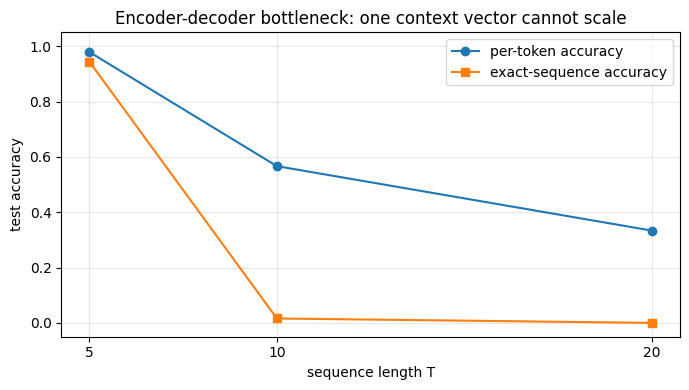

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lengths, tok, "o-", label="per-token accuracy")
ax.plot(lengths, seq, "s-", label="exact-sequence accuracy")
ax.set_xlabel("sequence length T")
ax.set_ylabel("test accuracy")
ax.set_title("Encoder-decoder bottleneck: one context vector cannot scale")
ax.set_xticks(lengths)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Lab B — concept check

**Q1. The unidirectional LSTM scored 0.756 on the future-context task, not 0.5.
If it genuinely cannot see t+1, why is it well above chance?**

Because the task isn't purely random with respect to the past. The inputs are
i.i.d. uniform, so in principle "is x[t+1] > x[t]?" is a coin flip given only the
history -- but two things lift the unidirectional model above 0.5. First, at the
boundary it can be right for free: the last position is always labelled 0, and
that's learnable from position alone. Second, the forward LSTM can hedge using
the value of x[t] itself: if x[t] is very large, the next draw is more likely to
be smaller (label 0), and if x[t] is very small, more likely larger (label 1).
That's a real statistical signal from the present value, not the future one, so
it buys accuracy above chance without ever solving the actual question. The
bidirectional model clears 0.98 because it can read the genuine answer at t+1.

**Q2. In the seq2seq sweep, per-token accuracy at T=20 was about 0.33 while
exact-sequence accuracy was 0.00. Reconcile those two numbers.**

They measure different things and the gap is the whole story. Per-token accuracy
is the fraction of individual positions predicted correctly; exact-sequence
accuracy demands every position in the sequence be right at once. At T=20 the
model still gets about a third of individual tokens -- likely the last few
encoded (nearest the context vector, freshest in memory) plus lucky guesses --
but getting all 20 simultaneously right is the product of 20 per-position
chances, so even 0.33 per token drives exact accuracy to essentially zero. The
divergence is diagnostic: it shows the failure is partial recall, not total
collapse. The context vector remembers the tail of the input and loses the head.

**Q3. We used teacher forcing (ratio 0.5) during training but turned it off
(0.0) at evaluation. Why, and how could that choice flatter the model?**

Teacher forcing feeds the ground-truth previous token into the decoder during
training instead of the decoder's own prediction, which stabilises and speeds up
learning -- early on the decoder's own outputs are garbage, and chaining garbage
into garbage gives no useful gradient. But it creates a train/test mismatch
("exposure bias"): at inference there are no ground-truth tokens, so the decoder
must consume its own predictions, and a single early mistake can derail the rest
of the sequence (errors compound). Evaluating with teacher forcing on would hide
exactly that failure mode -- the model would look far better than it is, because
each step would be handed the correct history regardless of its own errors.
Evaluating free-running (ratio 0.0) measures the model as it will actually be
used, which is why our bottleneck numbers are honest.

**Q4. The fix for this bottleneck is attention. In one sentence, what does
attention change about the information path?**

It removes the single fixed-size context vector as the only bridge between
encoder and decoder: instead of compressing the whole input into one vector,
attention lets the decoder look back at *all* encoder hidden states at every
output step and take a learned weighted combination of them, so information from
any input position can reach any output position directly -- no forced bottleneck,
and the path length between related tokens stops growing with sequence length.